# 📊 TARDIS Automated Test Generation — Data Science Analysis

**วัตถุประสงค์:** วิเคราะห์ผลการสร้างชุดทดสอบอัตโนมัติด้วย TARDIS บนบั๊กจริงจาก **Defects4J** ใน 3 มิติ
1. **Generation Performance** — สร้างเทสต์ได้เร็ว/มากแค่ไหน
2. **Code Coverage** — เทสต์ครอบคลุมโค้ดของ Buggy version เท่าไร
3. **Fault Detection** — เทสต์แยกแยะ Buggy กับ Fixed version ได้หรือไม่

**แหล่งข้อมูล (ที่มา):**
| ไฟล์ | สร้างโดย | ระดับข้อมูล |
|---|---|---|
| `Coverage_Result_All.csv` | `measure_coverage.py --all` | 1 แถว = 1 บั๊ก |
| `../TARDIS_Extended_Result.csv` | `run_tardis.py` | 1 แถว = 1 งาน (คลาส/เมธอด) |

> หลักการของ Notebook นี้: ทุกข้อสรุปคำนวณจากข้อมูลจริงใน cell นั้น ไม่มีข้อความสรุปที่เขียนตายตัว

## 0. โหลดข้อมูลและตรวจ Schema
**เหตุผล:** ค่าที่หาไม่ได้ถูกบันทึกเป็นข้อความ `"NaN"` จึงต้องแปลงเป็นตัวเลขก่อน และต้องตรวจว่า CSV เป็น schema ใหม่ (มี `Failing_Buggy`, `Failing_Fixed`, คอลัมน์ Generation) จริง

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# path แบบ relative: Notebook อยู่ใน Evaluator/
COV_PATH = '../result_csv/Coverage_Result_All.csv'
EXT_PATH = '../result_csv/TARDIS_Extended_Result.csv'

cov = pd.read_csv(COV_PATH)
ext = pd.read_csv(EXT_PATH)

REQUIRED = ['Failing_Buggy', 'Failing_Fixed', 'Fault_Detected', 'Eval_Status',
            'Gen_Time_sec', 'Saved_Tests_Count', 'Tests_per_Minute', 'Num_Test_Methods',
            'Compile_Time_sec', 'Test_ExecTime_sec']
missing = [c for c in REQUIRED if c not in cov.columns]
assert not missing, f'CSV เป็น schema เก่า ขาดคอลัมน์ {missing} -> รัน measure_coverage.py --all ใหม่'

num_cols = ['Total_Classes_Merged', 'Total_Methods_Merged', 'Num_Test_Methods', 'Test_Suite_LOC',
            'Gen_Time_sec', 'Saved_Tests_Count', 'Tests_per_Minute', 'Compile_Time_sec', 'Test_ExecTime_sec',
            'Line_Coverage(%)', 'Branch_Coverage(%)', 'Covered_Lines', 'Total_Lines',
            'Covered_Branches', 'Total_Branches', 'Failing_Buggy', 'Failing_Fixed']
for c in num_cols:
    cov[c] = pd.to_numeric(cov[c], errors='coerce')
ext['ExecTime_sec'] = pd.to_numeric(ext['ExecTime_sec'], errors='coerce')
ext['SavedTestsCount'] = pd.to_numeric(ext['SavedTestsCount'], errors='coerce')
ext['Status'] = ext['Status'].astype(str).str.strip()   # มี status ที่มีช่องว่างปน เช่น 'PARTIAL_SUCCESS '

print(f'Coverage CSV : {len(cov):,} บั๊ก, {cov["Project"].nunique()} โปรเจกต์')
print(f'Extended CSV : {len(ext):,} งาน, {ext["Project"].nunique()} โปรเจกต์')
cov.head()

Coverage CSV : 854 บั๊ก, 17 โปรเจกต์
Extended CSV : 8,661 งาน, 17 โปรเจกต์


,Project,BugID,Total_Classes_Merged,Total_Methods_Merged,Num_Test_Methods,Test_Suite_LOC,Gen_Time_sec,Saved_Tests_Count,Tests_per_Minute,Compile_Time_sec,...,Total_Lines,Covered_Branches,Total_Branches,Failing_Buggy,Failing_Fixed,Fault_Detected,Eval_Status,Runner_Status,Runner_Error,TimeoutLimit
0,Chart,1,1,0,NaN,NaN,120.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NO_TESTS,SETUP_FAIL | TIMEOUT,Unknown CLI Error | เกินเวลา 120 วินาที,0 | 120
1,Chart,2,1,1,1.0,340.0,200.00,2,0.600,12.71,...,801.0,7.0,544.0,0.0,0.0,NO,OK,DOCKER_FAIL | SUCCESS_ON_TIMEOUT,ERR: | OUT: t be found in this WSL 2 distro. ...,120
2,Chart,3,1,1,2.0,571.0,120.00,2,1.000,16.10,...,380.0,4.0,186.0,1.0,1.0,NO,OK,SETUP_FAIL | TIMEOUT,Unknown CLI Error | เกินเวลา 120 วินาที (เซฟทั...,0 | 120
3,Chart,4,1,0,NaN,NaN,120.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NO_TESTS,SETUP_FAIL | TIMEOUT,Cannot open config file (/home/windows_11/TARD...,0 | 120
4,Chart,5,1,1,1.0,256.0,442.45,8,1.085,12.41,...,172.0,0.0,80.0,0.0,0.0,NO,OK,DOCKER_FAIL | KILLED_WITH_TESTS,ERR: | OUT: t be found in this WSL 2 distro. ...,120


## 1. คุณภาพข้อมูล (Data Quality)
**ที่มา:** คอลัมน์ `Eval_Status` บอกว่าแต่ละบั๊กประเมินสำเร็จหรือล้มที่ขั้นไหน
**เหตุผล:** ถ้าไม่แยกบั๊กที่ประเมินไม่ได้ออก ค่าเฉลี่ยจะเบี้ยว และถ้านับ "ประเมินไม่ได้" เป็น "จับบั๊กไม่ได้" ตัวเลขจะต่ำกว่าความจริง

In [16]:
status_tbl = cov['Eval_Status'].value_counts().rename_axis('Eval_Status').to_frame('Bugs')
status_tbl['%'] = (status_tbl['Bugs'] / len(cov) * 100).round(1)
display(status_tbl)

na_tbl = cov[num_cols].isna().mean().mul(100).round(1).sort_values(ascending=False).to_frame('% Missing')
display(na_tbl.head(10))

n_ok = (cov['Eval_Status'] == 'OK').sum()
print('📌 สรุปความหมาย:')
print(f'  - ประเมินได้ครบ (Eval_Status=OK): {n_ok}/{len(cov)} บั๊ก ({n_ok/max(len(cov),1)*100:.1f}%)')
print(f'  - สาเหตุที่ประเมินไม่ได้มากที่สุด: {status_tbl.drop("OK", errors="ignore").index[0] if len(status_tbl.drop("OK", errors="ignore")) else "-"}')
print('  - การวิเคราะห์ Coverage/Fault Detection ต่อจากนี้ใช้เฉพาะบั๊กที่ประเมินได้ จึงต้องระบุ n ทุกครั้ง')

,Bugs,%
Eval_Status,,
OK,545,63.8
NO_TESTS,298,34.9
BUGGY_TEST_COMPILE_OR_RUN_FAIL,7,0.8
FIXED_TEST_COMPILE_FAIL,4,0.5


,% Missing
Failing_Fixed,36.2
Branch_Coverage(%),35.7
Failing_Buggy,35.7
Covered_Branches,35.7
Total_Branches,35.7
Line_Coverage(%),35.7
Covered_Lines,35.7
Total_Lines,35.7
Test_ExecTime_sec,34.9
Test_Suite_LOC,34.9


📌 สรุปความหมาย:
  - ประเมินได้ครบ (Eval_Status=OK): 545/854 บั๊ก (63.8%)
  - สาเหตุที่ประเมินไม่ได้มากที่สุด: NO_TESTS
  - การวิเคราะห์ Coverage/Fault Detection ต่อจากนี้ใช้เฉพาะบั๊กที่ประเมินได้ จึงต้องระบุ n ทุกครั้ง


## 2. สถานะการรัน TARDIS (Generation Outcome)
**ที่มา:** คอลัมน์ `Status` ใน `TARDIS_Extended_Result.csv` (ระดับงาน)
**เหตุผล:** การจะสร้างเทสต์ได้ TARDIS ต้องรันผ่านก่อน สถานะการรันจึงเป็นตัวกำหนดว่าเราจะมีเทสต์มาวัดผลมากแค่ไหน
**นิยามกลุ่ม:** สำเร็จ = มีโอกาสได้ไฟล์เทสต์ (`COMPLETED`, `SUCCESS_ON_TIMEOUT`, `KILLED_WITH_TESTS`, `PARTIAL_SUCCESS`, `FALLBACK_DONE`), ข้าม = ไม่มีเป้าหมายหรือไม่ได้เทสต์, ล้มเหลว = นอกเหนือจากนั้น

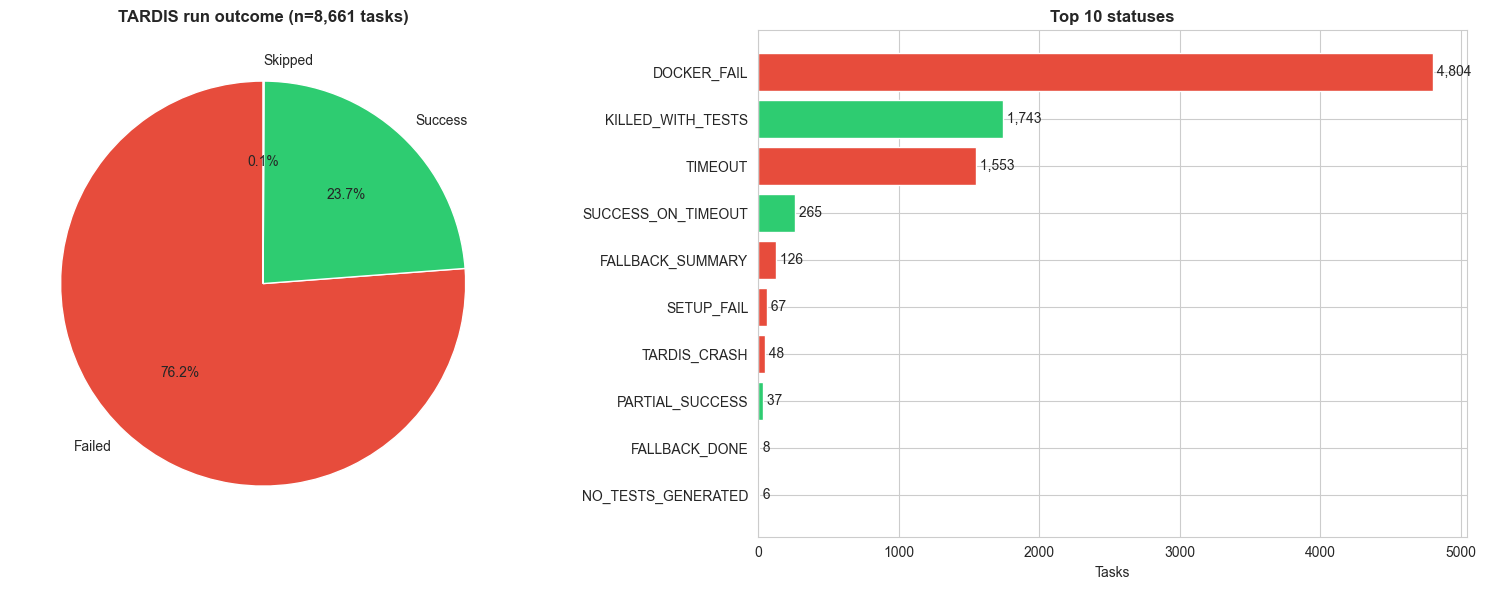

📌 สรุปความหมาย:
  - Success : 2,056 งาน (23.7%)
  - Skipped : 6 งาน (0.1%)
  - Failed  : 6,599 งาน (76.2%)
  - สถานะที่พบบ่อยที่สุดคือ DOCKER_FAIL (4,804 งาน)


In [17]:
SUCCESS = {'COMPLETED', 'SUCCESS_ON_TIMEOUT', 'KILLED_WITH_TESTS', 'PARTIAL_SUCCESS', 'FALLBACK_DONE'}
SKIP = {'NO_MODIFIED_CLASSES', 'NO_TESTS_GENERATED'}
ext['Group'] = np.where(ext['Status'].isin(SUCCESS), 'Success',
               np.where(ext['Status'].isin(SKIP), 'Skipped', 'Failed'))
grp = ext['Group'].value_counts()
top = ext['Status'].value_counts().head(10)
cmap = {'Success': '#2ecc71', 'Skipped': '#f39c12', 'Failed': '#e74c3c'}

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].pie(grp.values, labels=grp.index, autopct='%1.1f%%', colors=[cmap[g] for g in grp.index], startangle=90)
ax[0].set_title(f'TARDIS run outcome (n={len(ext):,} tasks)', fontweight='bold')
colors = [cmap['Success'] if s in SUCCESS else cmap['Skipped'] if s in SKIP else cmap['Failed'] for s in top.index]
ax[1].barh(top.index[::-1], top.values[::-1], color=colors[::-1])
for i, v in enumerate(top.values[::-1]):
    ax[1].text(v, i, f' {v:,}', va='center')
ax[1].set_xlabel('Tasks'); ax[1].set_title('Top 10 statuses', fontweight='bold')
plt.tight_layout(); plt.savefig('01_status_overview.png', dpi=150, bbox_inches='tight'); plt.show()

print('📌 สรุปความหมาย:')
for g in ['Success', 'Skipped', 'Failed']:
    print(f'  - {g:8s}: {grp.get(g, 0):,} งาน ({grp.get(g, 0)/len(ext)*100:.1f}%)')
print(f'  - สถานะที่พบบ่อยที่สุดคือ {top.index[0]} ({top.iloc[0]:,} งาน)')

## 3. อัตราความสำเร็จรายโปรเจกต์
**เหตุผล:** แต่ละโปรเจกต์มีความซับซ้อนต่างกัน (ขนาดโค้ด, ประเภทข้อมูล, การใช้ reflection) การเทียบรายโปรเจกต์ช่วยให้เห็นว่า TARDIS เหมาะกับโค้ดแบบไหน
**สูตร:** Success rate = งานในกลุ่ม Success / งานทั้งหมดของโปรเจกต์ (ไม่นับงานกลุ่ม Skipped)

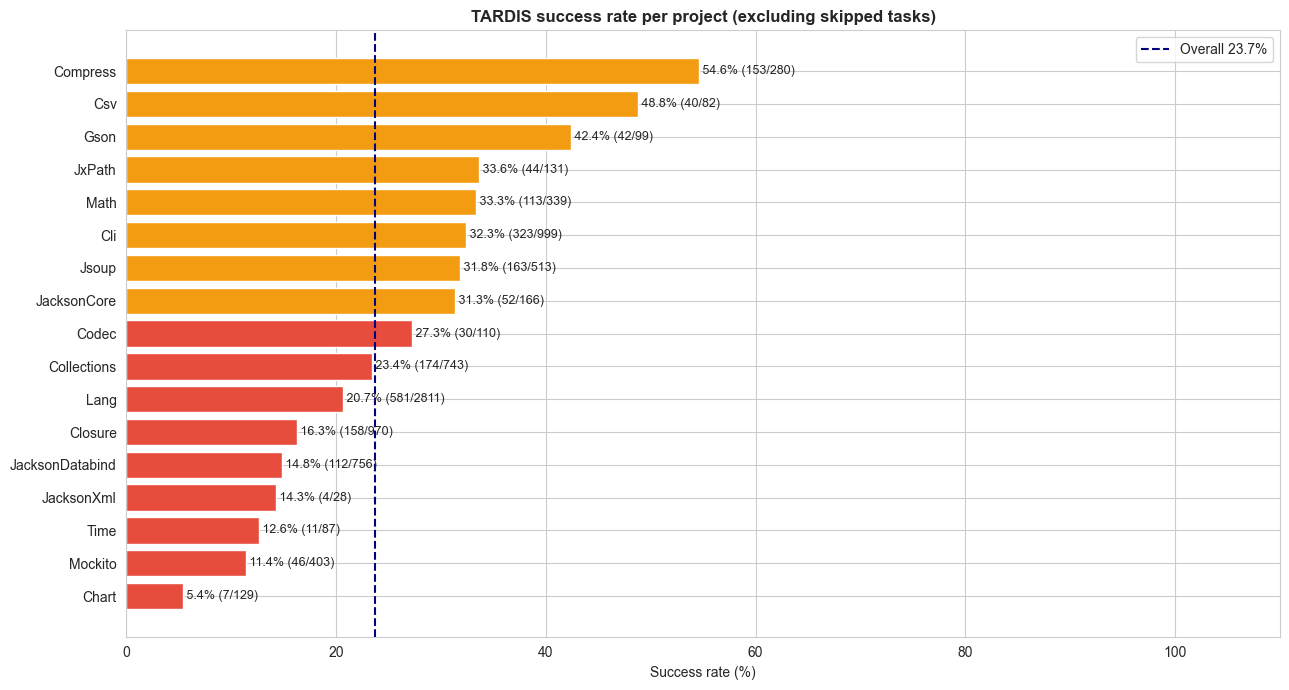

📌 สรุปความหมาย:
  - อัตราสำเร็จรวม (ถ่วงน้ำหนักตามจำนวนงาน): 23.7%
  - สูงสุด: Compress (54.6%), ต่ำสุด: Chart (5.4%)
  - ส่วนต่างระหว่างโปรเจกต์ 49.2 จุด แปลว่าลักษณะของโปรเจกต์มีผลต่อความสำเร็จอย่างมาก


In [18]:
e2 = ext[ext['Group'] != 'Skipped']
ps = e2.groupby('Project')['Group'].agg(total='count', success=lambda s: (s == 'Success').sum())
ps['rate'] = ps['success'] / ps['total'] * 100
ps = ps.sort_values('rate')

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(ps.index, ps['rate'], color=['#e74c3c' if r < 30 else '#f39c12' if r < 60 else '#2ecc71' for r in ps['rate']])
for i, (r, s, t) in enumerate(zip(ps['rate'], ps['success'], ps['total'])):
    ax.text(r, i, f' {r:.1f}% ({s}/{t})', va='center', fontsize=9)
overall = ps['success'].sum() / ps['total'].sum() * 100
ax.axvline(overall, ls='--', color='navy', label=f'Overall {overall:.1f}%')
ax.set_xlim(0, 110); ax.set_xlabel('Success rate (%)'); ax.legend()
ax.set_title('TARDIS success rate per project (excluding skipped tasks)', fontweight='bold')
plt.tight_layout(); plt.savefig('02_success_rate_per_project.png', dpi=150, bbox_inches='tight'); plt.show()

print('📌 สรุปความหมาย:')
print(f'  - อัตราสำเร็จรวม (ถ่วงน้ำหนักตามจำนวนงาน): {overall:.1f}%')
print(f'  - สูงสุด: {ps.index[-1]} ({ps["rate"].iloc[-1]:.1f}%), ต่ำสุด: {ps.index[0]} ({ps["rate"].iloc[0]:.1f}%)')
print(f'  - ส่วนต่างระหว่างโปรเจกต์ {ps["rate"].iloc[-1]-ps["rate"].iloc[0]:.1f} จุด แปลว่าลักษณะของโปรเจกต์มีผลต่อความสำเร็จอย่างมาก')

## 4. Generation Performance (ประสิทธิภาพการสร้างเทสต์)
**ที่มา:**
- `Gen_Time_sec` = ผลรวม `ExecTime_sec` ของทุกงานของบั๊กนั้น (เวลาที่ TARDIS ใช้จริง)
- `Saved_Tests_Count` = ผลรวม `SavedTestsCount` (จำนวนไฟล์เทสต์ที่เก็บได้)
- `Tests_per_Minute` = `Saved_Tests_Count / (Gen_Time_sec / 60)`
- `Num_Test_Methods` = จำนวน `@Test` ในชุดเทสต์หลังรวม

**เหตุผล:** Coverage อย่างเดียวไม่พอ เครื่องมือที่ได้ coverage เท่ากันแต่ใช้เวลาน้อยกว่าถือว่าดีกว่า ตัวชี้วัดนี้ตอบคำถามว่า "แลกเวลาไปเท่าไร ได้อะไรกลับมา"

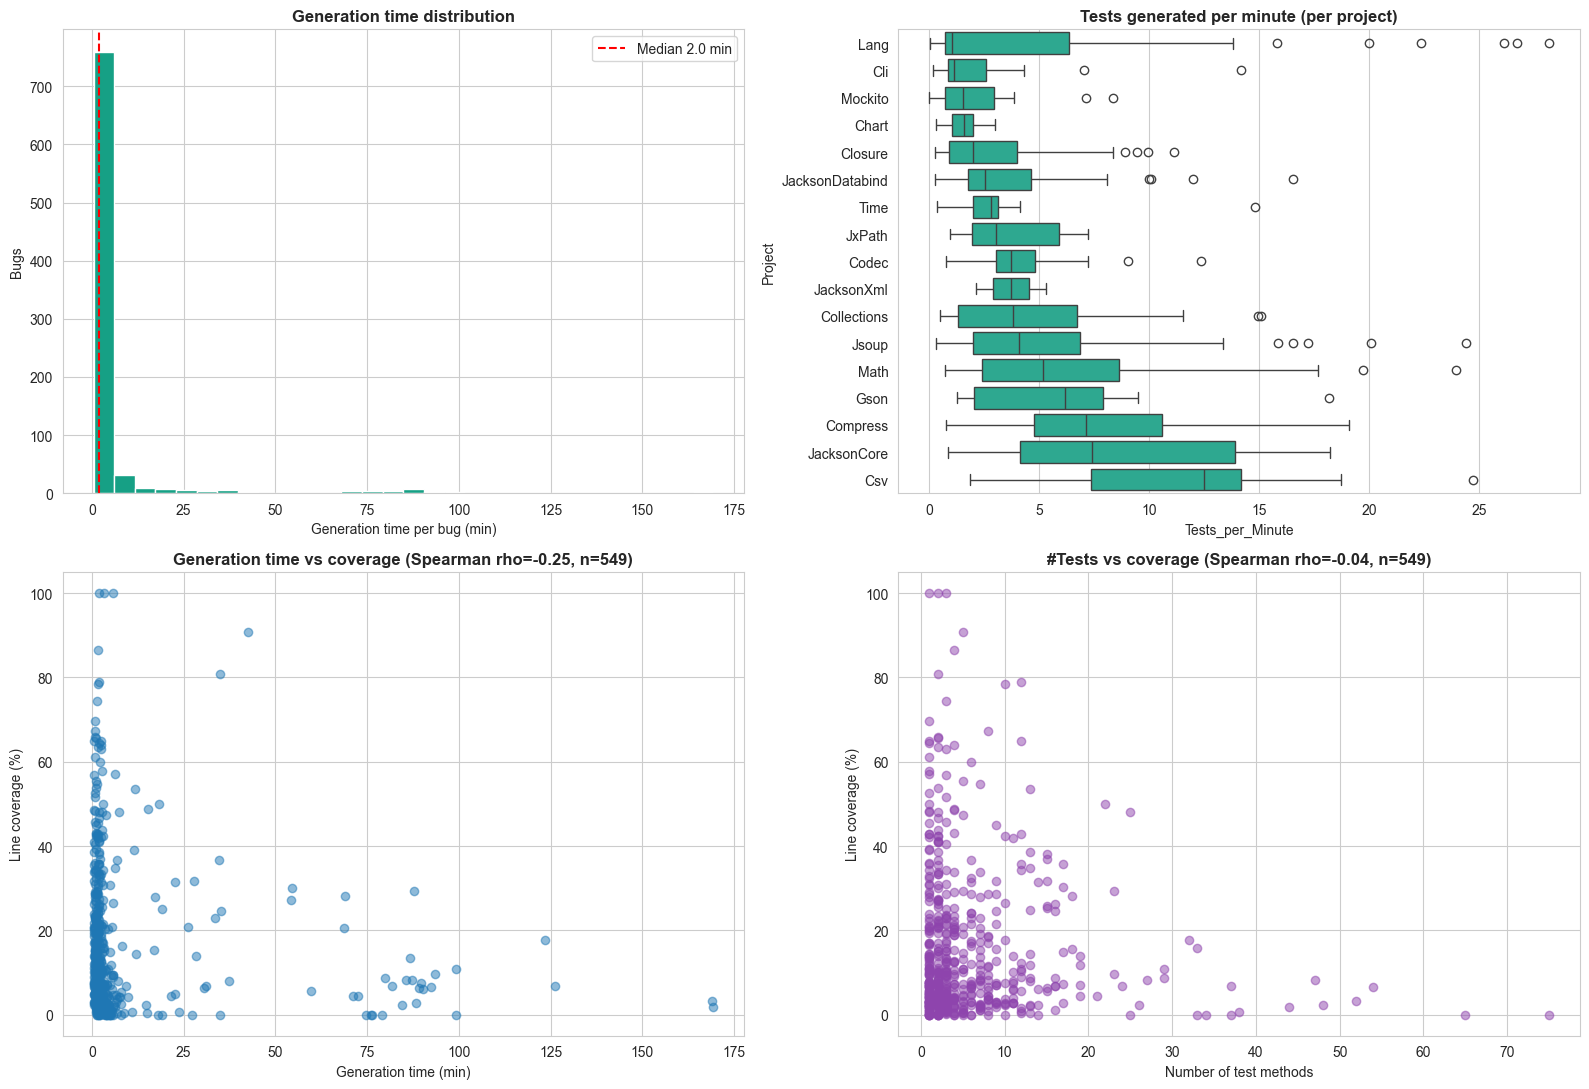

📌 สรุปความหมาย:
  - เวลาสร้างเทสต์ต่อบั๊ก: มัธยฐาน 2.0 นาที, เฉลี่ย 6.1 นาที (n=854)
  - อัตราการสร้าง: มัธยฐาน 3.02 ไฟล์เทสต์/นาที
  - เวลา vs Coverage: ความสัมพันธ์อ่อน (ลบ) -> การให้เวลามากขึ้นอย่างเดียวไม่ได้รับประกันว่าจะได้ coverage มากขึ้น
  - จำนวนเทสต์ vs Coverage: ความสัมพันธ์แทบไม่มี (ลบ)
  - ใช้ Spearman เพราะข้อมูลเบ้และมี outlier (ไม่ได้แจกแจงแบบปกติ)


In [19]:
g = cov.dropna(subset=['Gen_Time_sec'])
fig, ax = plt.subplots(2, 2, figsize=(16, 11))

ax[0,0].hist(g['Gen_Time_sec'] / 60, bins=30, color='#16a085', edgecolor='white')
ax[0,0].axvline(g['Gen_Time_sec'].median() / 60, color='red', ls='--', label=f"Median {g['Gen_Time_sec'].median()/60:.1f} min")
ax[0,0].set_xlabel('Generation time per bug (min)'); ax[0,0].set_ylabel('Bugs'); ax[0,0].legend()
ax[0,0].set_title('Generation time distribution', fontweight='bold')

tpm = g.dropna(subset=['Tests_per_Minute'])
order = tpm.groupby('Project')['Tests_per_Minute'].median().sort_values().index
sns.boxplot(data=tpm, y='Project', x='Tests_per_Minute', order=order, ax=ax[0,1], color='#1abc9c')
ax[0,1].set_title('Tests generated per minute (per project)', fontweight='bold')

sc = g.dropna(subset=['Line_Coverage(%)'])
ax[1,0].scatter(sc['Gen_Time_sec'] / 60, sc['Line_Coverage(%)'], alpha=0.5)
rho_t = sc['Gen_Time_sec'].corr(sc['Line_Coverage(%)'], method='spearman') if len(sc) > 2 else np.nan
ax[1,0].set_xlabel('Generation time (min)'); ax[1,0].set_ylabel('Line coverage (%)')
ax[1,0].set_title(f'Generation time vs coverage (Spearman rho={rho_t:.2f}, n={len(sc)})', fontweight='bold')

sc2 = cov.dropna(subset=['Num_Test_Methods', 'Line_Coverage(%)'])
ax[1,1].scatter(sc2['Num_Test_Methods'], sc2['Line_Coverage(%)'], alpha=0.5, color='#8e44ad')
rho_n = sc2['Num_Test_Methods'].corr(sc2['Line_Coverage(%)'], method='spearman') if len(sc2) > 2 else np.nan
ax[1,1].set_xlabel('Number of test methods'); ax[1,1].set_ylabel('Line coverage (%)')
ax[1,1].set_title(f'#Tests vs coverage (Spearman rho={rho_n:.2f}, n={len(sc2)})', fontweight='bold')
plt.tight_layout(); plt.savefig('03_generation_performance.png', dpi=150, bbox_inches='tight'); plt.show()

def rho_text(r):
    if pd.isna(r): return 'ข้อมูลไม่พอ'
    a = abs(r)
    s = 'แทบไม่มี' if a < 0.1 else 'อ่อน' if a < 0.3 else 'ปานกลาง' if a < 0.5 else 'สูง'
    return f'{s} ({"บวก" if r > 0 else "ลบ"})'

print('📌 สรุปความหมาย:')
print(f'  - เวลาสร้างเทสต์ต่อบั๊ก: มัธยฐาน {g["Gen_Time_sec"].median()/60:.1f} นาที, เฉลี่ย {g["Gen_Time_sec"].mean()/60:.1f} นาที (n={len(g)})')
print(f'  - อัตราการสร้าง: มัธยฐาน {tpm["Tests_per_Minute"].median():.2f} ไฟล์เทสต์/นาที')
print(f'  - เวลา vs Coverage: ความสัมพันธ์{rho_text(rho_t)} -> ' +
      ('ให้เวลามากขึ้นมีแนวโน้มได้ coverage มากขึ้น' if rho_t >= 0.3 else 'การให้เวลามากขึ้นอย่างเดียวไม่ได้รับประกันว่าจะได้ coverage มากขึ้น'))
print(f'  - จำนวนเทสต์ vs Coverage: ความสัมพันธ์{rho_text(rho_n)}')
print('  - ใช้ Spearman เพราะข้อมูลเบ้และมี outlier (ไม่ได้แจกแจงแบบปกติ)')

## 5. การกระจายตัวของ Coverage
**ที่มา:** `defects4j coverage` (Cobertura) ที่รันบน **Buggy version** วัดเฉพาะคลาสที่ถูกแก้ในบั๊กนั้น
**เหตุผล:** Coverage บอกว่าเทสต์ได้ "เดินผ่าน" โค้ดส่วนที่มีบั๊กหรือไม่ ซึ่งเป็นเงื่อนไขจำเป็น (แต่ยังไม่พอ) ของการจับบั๊ก

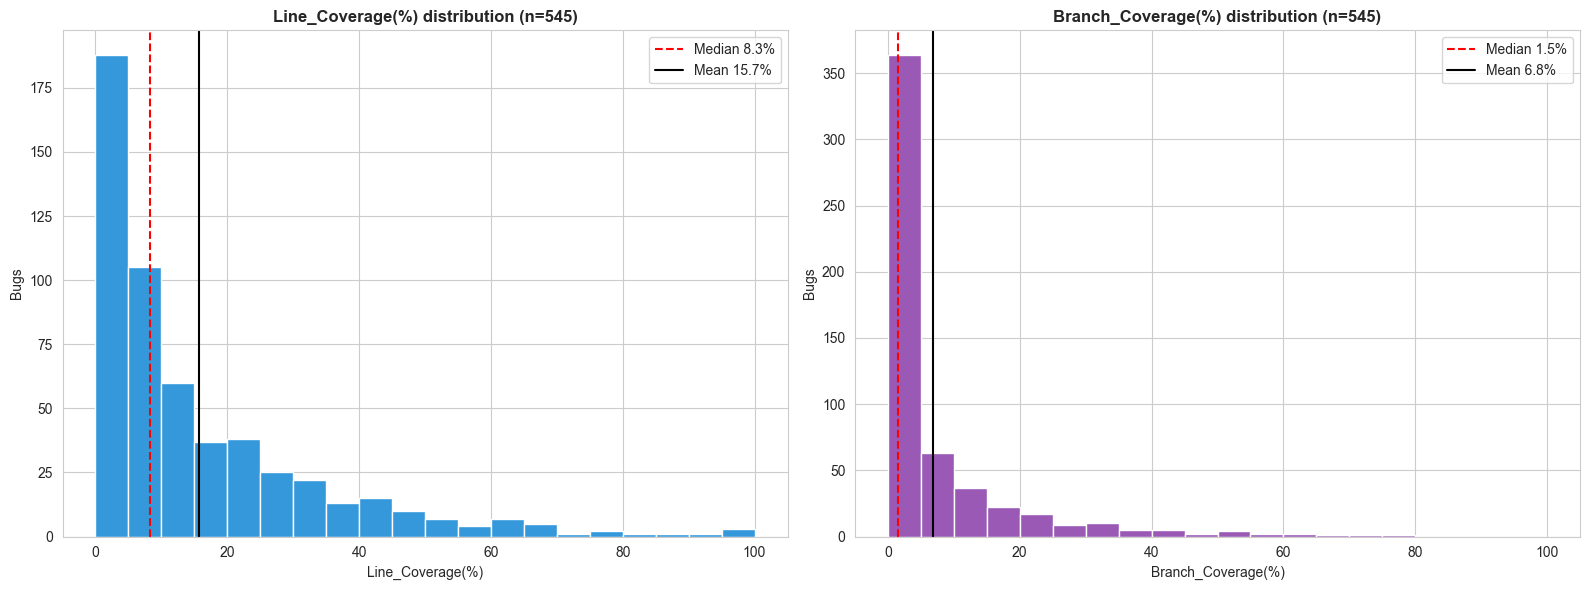

📌 สรุปความหมาย:
  - Line  : เฉลี่ย 15.7%, มัธยฐาน 8.3%, ได้ 0% อยู่ 4.4% ของบั๊ก
  - Branch: เฉลี่ย 6.8%, มัธยฐาน 1.5%
  - ความเบ้ (skew) ของ Line coverage = 1.92 -> เบ้ขวา: บั๊กส่วนใหญ่ได้ coverage ต่ำ มีส่วนน้อยที่ได้สูง
  - Branch ต่ำกว่า Line โดยเฉลี่ย 8.8 จุด เพราะต้องครอบคลุมทั้งด้าน true และ false ของทุกเงื่อนไข


In [20]:
cv = cov[cov['Eval_Status'] == 'OK'].dropna(subset=['Line_Coverage(%)'])
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, col, c in [(ax[0], 'Line_Coverage(%)', '#3498db'), (ax[1], 'Branch_Coverage(%)', '#9b59b6')]:
    d = cv[col].dropna()
    a.hist(d, bins=20, range=(0, 100), color=c, edgecolor='white')
    a.axvline(d.median(), color='red', ls='--', label=f'Median {d.median():.1f}%')
    a.axvline(d.mean(), color='black', label=f'Mean {d.mean():.1f}%')
    a.set_xlabel(col); a.set_ylabel('Bugs'); a.legend()
    a.set_title(f'{col} distribution (n={len(d)})', fontweight='bold')
plt.tight_layout(); plt.savefig('04_coverage_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

L, B = cv['Line_Coverage(%)'], cv['Branch_Coverage(%)'].dropna()
print('📌 สรุปความหมาย:')
print(f'  - Line  : เฉลี่ย {L.mean():.1f}%, มัธยฐาน {L.median():.1f}%, ได้ 0% อยู่ {(L==0).mean()*100:.1f}% ของบั๊ก')
print(f'  - Branch: เฉลี่ย {B.mean():.1f}%, มัธยฐาน {B.median():.1f}%')
print(f'  - ความเบ้ (skew) ของ Line coverage = {L.skew():.2f} -> ' +
      ('เบ้ขวา: บั๊กส่วนใหญ่ได้ coverage ต่ำ มีส่วนน้อยที่ได้สูง' if L.skew() > 0.5 else
       'เบ้ซ้าย: บั๊กส่วนใหญ่ได้ coverage สูง' if L.skew() < -0.5 else 'ค่อนข้างสมมาตร'))
print(f'  - Branch ต่ำกว่า Line โดยเฉลี่ย {L.mean()-B.mean():.1f} จุด เพราะต้องครอบคลุมทั้งด้าน true และ false ของทุกเงื่อนไข')

## 6. Coverage รายโปรเจกต์
**เหตุผล:** ใช้ตอบว่า Symbolic/Concolic execution ได้ผลดีกับโค้ดแบบไหน

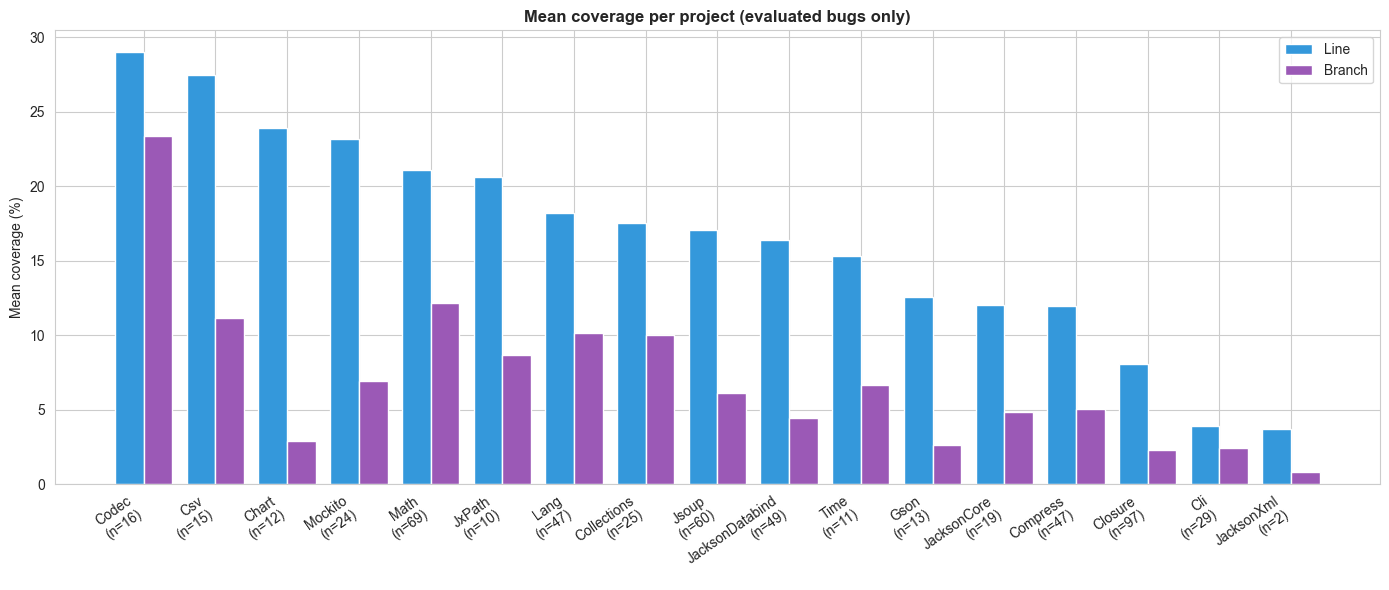

📌 สรุปความหมาย:
  - สูงสุด: Codec (Line 29.0%, n=16)
  - ต่ำสุด: JacksonXml (Line 3.7%, n=2)
  - ⚠️ โปรเจกต์ที่มี n<5 (JacksonXml) ค่าเฉลี่ยยังไม่น่าเชื่อถือทางสถิติ


In [21]:
pc = cv.groupby('Project').agg(line=('Line_Coverage(%)', 'mean'), branch=('Branch_Coverage(%)', 'mean'),
                               n=('BugID', 'count')).sort_values('line', ascending=False)
x = np.arange(len(pc))
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.2, pc['line'], 0.4, label='Line', color='#3498db')
ax.bar(x + 0.2, pc['branch'], 0.4, label='Branch', color='#9b59b6')
ax.set_xticks(x); ax.set_xticklabels([f'{p}\n(n={n})' for p, n in zip(pc.index, pc['n'])], rotation=35, ha='right')
ax.set_ylabel('Mean coverage (%)'); ax.legend()
ax.set_title('Mean coverage per project (evaluated bugs only)', fontweight='bold')
plt.tight_layout(); plt.savefig('05_coverage_per_project.png', dpi=150, bbox_inches='tight'); plt.show()

print('📌 สรุปความหมาย:')
print(f'  - สูงสุด: {pc.index[0]} (Line {pc["line"].iloc[0]:.1f}%, n={pc["n"].iloc[0]})')
print(f'  - ต่ำสุด: {pc.index[-1]} (Line {pc["line"].iloc[-1]:.1f}%, n={pc["n"].iloc[-1]})')
small = pc[pc['n'] < 5].index.tolist()
if small:
    print(f'  - ⚠️ โปรเจกต์ที่มี n<5 ({", ".join(small)}) ค่าเฉลี่ยยังไม่น่าเชื่อถือทางสถิติ')

## 7. Fault Detection: Buggy vs Fixed
**ที่มา:** ชุดเทสต์เดียวกันถูกรันทั้งบน `{bug}b` (Buggy) และ `{bug}f` (Fixed)
- `Failing_Buggy` = จำนวนเทสต์ที่ fail บน Buggy
- `Failing_Fixed` = จำนวนเทสต์ที่ fail บน Fixed
- `Fault_Detected = YES` ถ้ามีเทสต์ที่ **fail บน Fixed แต่ผ่านบน Buggy** (เทียบเป็นชื่อเทสต์ทีละตัว)

**เหตุผลเชิงวิธีวิจัย:** TARDIS สร้างเทสต์จาก **Buggy version** assertion ในเทสต์จึงบันทึกพฤติกรรมตอนที่ยังมีบั๊กอยู่ ถ้าเทสต์ fail บน Fixed แปลว่าเทสต์ **ตรวจพบพฤติกรรมที่เปลี่ยนไปจากการแก้บั๊ก** ซึ่งต่างจากวิธีมาตรฐานในงานวิจัย (สร้างจาก Fixed แล้วไปรันบน Buggy) และควรระบุข้อนี้ไว้ในรายงาน
บั๊กที่ Eval_Status ไม่ใช่ OK (เช่น Fixed compile ไม่ผ่าน) จะ **ไม่ถูกนับ** เป็น NO

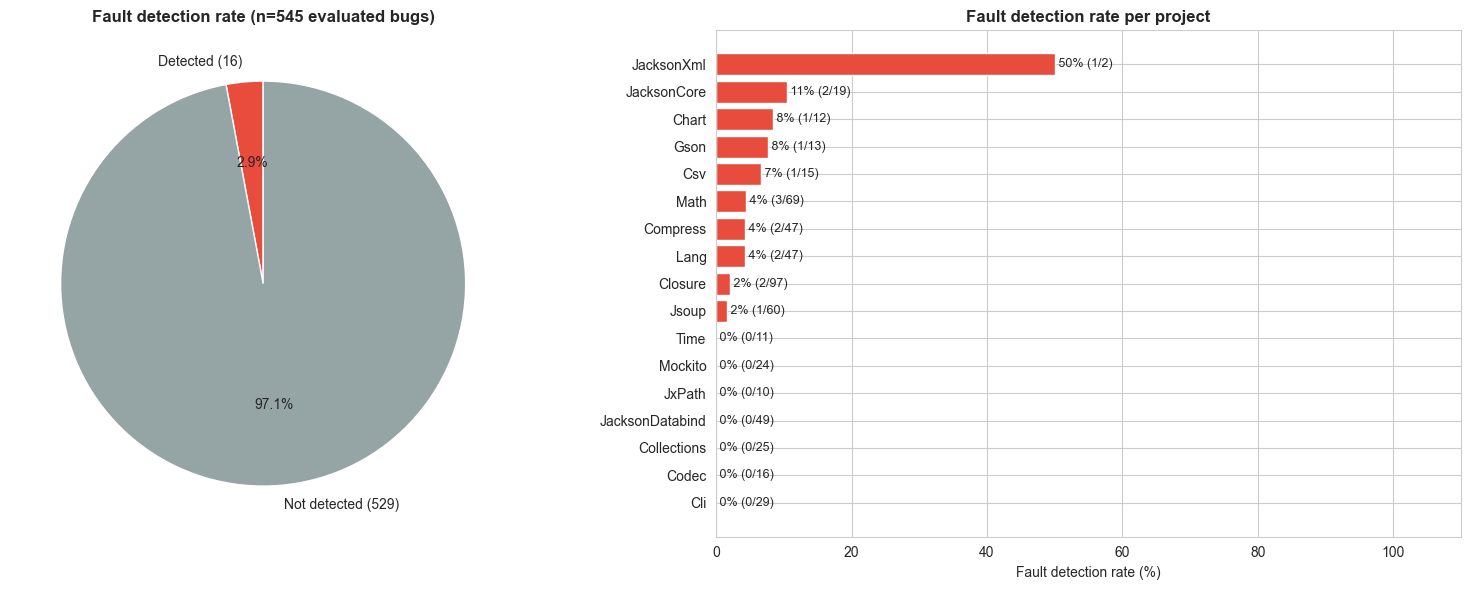

📌 สรุปความหมาย:
  - ตรวจพบ 16/545 บั๊ก (2.9%)
  - ตรวจสมมติฐาน: บั๊กที่ Failing_Buggy = 0 มี 89.0%
    -> มีเทสต์ที่ fail บน Buggy เองด้วย (อาจเป็น flaky หรือเทสต์ขึ้นกับสภาพแวดล้อม) จึงต้องเทียบเป็นชื่อเทสต์ ไม่ใช่เทียบแค่จำนวน
  - Failing_Fixed เฉลี่ย 0.76 เทสต์/บั๊ก, Failing_Buggy เฉลี่ย 0.71


In [22]:
fd = cov[cov['Eval_Status'] == 'OK'].copy()
n_eval = len(fd)
n_yes = (fd['Fault_Detected'] == 'YES').sum()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
if n_eval:
    ax[0].pie([n_yes, n_eval - n_yes], labels=[f'Detected ({n_yes})', f'Not detected ({n_eval-n_yes})'],
              colors=['#e74c3c', '#95a5a6'], autopct='%1.1f%%', startangle=90)
ax[0].set_title(f'Fault detection rate (n={n_eval} evaluated bugs)', fontweight='bold')

proj_fd = fd.groupby('Project')['Fault_Detected'].agg(n='count', yes=lambda s: (s == 'YES').sum())
proj_fd['rate'] = proj_fd['yes'] / proj_fd['n'] * 100
proj_fd = proj_fd.sort_values('rate')
ax[1].barh(proj_fd.index, proj_fd['rate'], color='#e74c3c')
for i, (r, y, n) in enumerate(zip(proj_fd['rate'], proj_fd['yes'], proj_fd['n'])):
    ax[1].text(r, i, f' {r:.0f}% ({y}/{n})', va='center', fontsize=9)
ax[1].set_xlim(0, 110); ax[1].set_xlabel('Fault detection rate (%)')
ax[1].set_title('Fault detection rate per project', fontweight='bold')
plt.tight_layout(); plt.savefig('06_fault_detection.png', dpi=150, bbox_inches='tight'); plt.show()

# ตรวจสมมติฐาน: เทสต์ที่สร้างจาก Buggy ควรผ่านบน Buggy (Failing_Buggy = 0)
pass_on_buggy = (fd['Failing_Buggy'] == 0).mean() * 100 if n_eval else np.nan
print('📌 สรุปความหมาย:')
print(f'  - ตรวจพบ {n_yes}/{n_eval} บั๊ก ({n_yes/max(n_eval,1)*100:.1f}%)')
print(f'  - ตรวจสมมติฐาน: บั๊กที่ Failing_Buggy = 0 มี {pass_on_buggy:.1f}%')
if pass_on_buggy < 100:
    print('    -> มีเทสต์ที่ fail บน Buggy เองด้วย (อาจเป็น flaky หรือเทสต์ขึ้นกับสภาพแวดล้อม) จึงต้องเทียบเป็นชื่อเทสต์ ไม่ใช่เทียบแค่จำนวน')
print(f'  - Failing_Fixed เฉลี่ย {fd["Failing_Fixed"].mean():.2f} เทสต์/บั๊ก, Failing_Buggy เฉลี่ย {fd["Failing_Buggy"].mean():.2f}')

## 8. Coverage สัมพันธ์กับการจับบั๊กหรือไม่?
**สมมติฐาน (H1):** บั๊กที่ตรวจพบมี coverage สูงกว่าบั๊กที่ตรวจไม่พบ
**วิธีทดสอบ:** Mann-Whitney U test (ไม่ต้องสมมติว่าข้อมูลแจกแจงแบบปกติ เหมาะกับข้อมูลที่เบ้) ใช้ α = 0.05

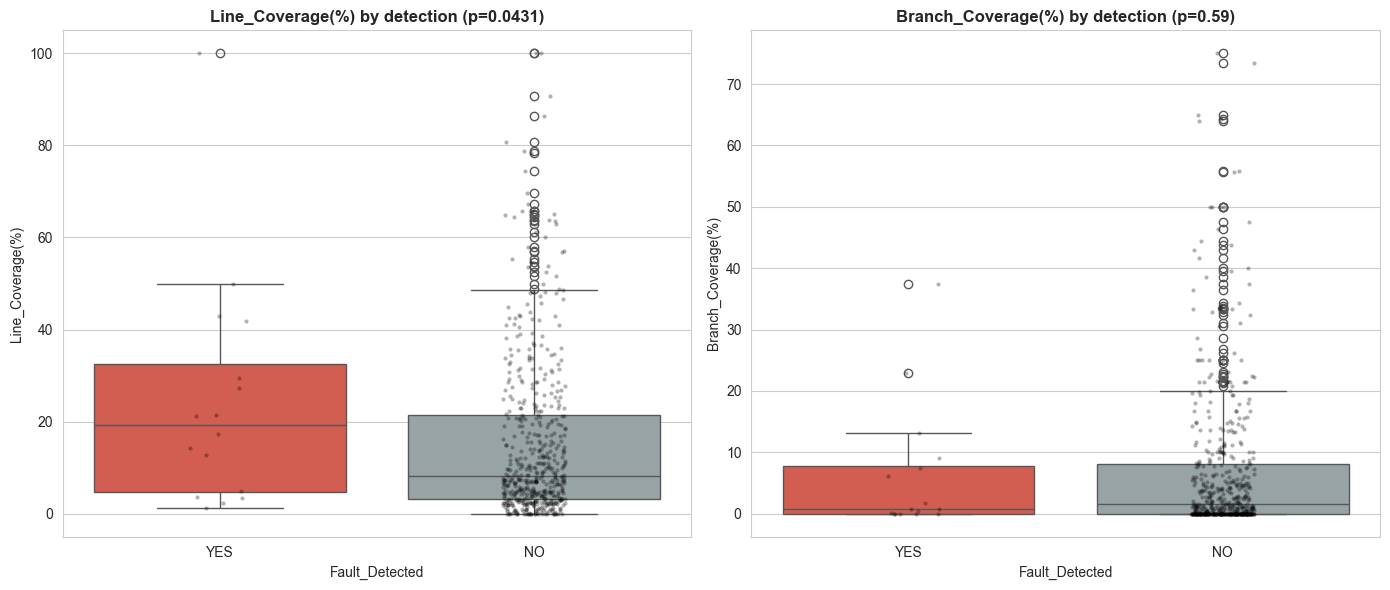

📌 สรุปความหมาย:
  - Line_Coverage(%): median YES=19.2% (n=16) vs NO=8.2% (n=529), p=0.0431 -> มีนัยสำคัญ -> สนับสนุน H1
  - Branch_Coverage(%): median YES=0.8% (n=16) vs NO=1.5% (n=529), p=0.59 -> ไม่มีนัยสำคัญ -> ยังสรุปไม่ได้ว่า coverage สูงช่วยให้จับบั๊กได้


In [23]:
try:
    from scipy.stats import mannwhitneyu
except ImportError:
    mannwhitneyu = None

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
results = {}
for a, col in [(ax[0], 'Line_Coverage(%)'), (ax[1], 'Branch_Coverage(%)')]:
    d = fd.dropna(subset=[col])
    sns.boxplot(data=d, x='Fault_Detected', y=col, order=['YES', 'NO'], ax=a,
                palette={'YES': '#e74c3c', 'NO': '#95a5a6'})
    sns.stripplot(data=d, x='Fault_Detected', y=col, order=['YES', 'NO'], ax=a, color='black', alpha=0.3, size=3)
    y, n = d[d['Fault_Detected'] == 'YES'][col], d[d['Fault_Detected'] == 'NO'][col]
    p = mannwhitneyu(y, n, alternative='greater').pvalue if (mannwhitneyu and len(y) > 1 and len(n) > 1) else np.nan
    results[col] = (y.median(), n.median(), p, len(y), len(n))
    a.set_title(f'{col} by detection (p={p:.3g})', fontweight='bold')
plt.tight_layout(); plt.savefig('07_coverage_vs_detection.png', dpi=150, bbox_inches='tight'); plt.show()

print('📌 สรุปความหมาย:')
for col, (my, mn, p, ny, nn) in results.items():
    verdict = ('ข้อมูลไม่พอ/ไม่มี scipy' if pd.isna(p) else
               'มีนัยสำคัญ -> สนับสนุน H1' if p < 0.05 else 'ไม่มีนัยสำคัญ -> ยังสรุปไม่ได้ว่า coverage สูงช่วยให้จับบั๊กได้')
    print(f'  - {col}: median YES={my:.1f}% (n={ny}) vs NO={mn:.1f}% (n={nn}), p={p:.3g} -> {verdict}')

## 9. ต้นทุนการประเมิน: เวลา Compile vs เวลารันเทสต์
**ที่มา:** `measure_coverage.py` สั่ง `defects4j compile` แยกออกมาก่อน (`Compile_Time_sec`) แล้วจึงรัน `defects4j coverage` (`Test_ExecTime_sec` ซึ่งรวมเวลา compile เทสต์, instrument และรันเทสต์บน Buggy)
**เหตุผล:** ใช้ดูว่าเวลาประเมินหมดไปกับอะไร ถ้าอยากลดเวลาจะได้รู้ว่าต้องไปลดตรงไหน

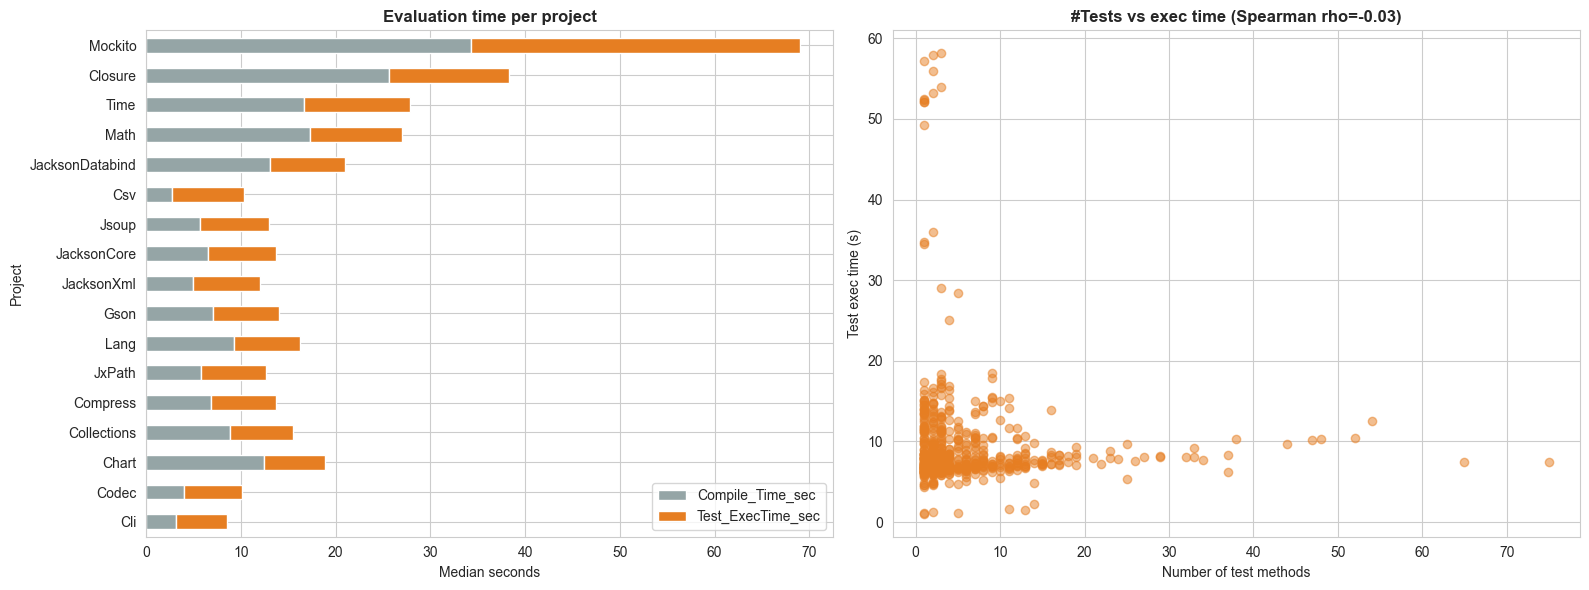

📌 สรุปความหมาย:
  - Compile โปรเจกต์: มัธยฐาน 10.5s | รันเทสต์+coverage: มัธยฐาน 7.8s (n=556)
  - เวลาต่อ 1 test method: มัธยฐาน 2.505s
  - #Tests กับเวลา: Spearman rho=-0.03 -> เวลาส่วนใหญ่เป็นค่า overhead คงที่ (JVM/ant/instrument) ไม่ได้ขึ้นกับจำนวนเทสต์


In [24]:
t = cov.dropna(subset=['Compile_Time_sec', 'Test_ExecTime_sec'])
tp = t.groupby('Project')[['Compile_Time_sec', 'Test_ExecTime_sec']].median().sort_values('Test_ExecTime_sec')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
tp.plot.barh(stacked=True, ax=ax[0], color=['#95a5a6', '#e67e22'])
ax[0].set_xlabel('Median seconds'); ax[0].set_title('Evaluation time per project', fontweight='bold')
ax[1].scatter(t['Num_Test_Methods'], t['Test_ExecTime_sec'], alpha=0.5, color='#e67e22')
rho_e = t['Num_Test_Methods'].corr(t['Test_ExecTime_sec'], method='spearman') if len(t) > 2 else np.nan
ax[1].set_xlabel('Number of test methods'); ax[1].set_ylabel('Test exec time (s)')
ax[1].set_title(f'#Tests vs exec time (Spearman rho={rho_e:.2f})', fontweight='bold')
plt.tight_layout(); plt.savefig('08_evaluation_cost.png', dpi=150, bbox_inches='tight'); plt.show()

per_test = (t['Test_ExecTime_sec'] / t['Num_Test_Methods'].replace(0, np.nan)).dropna()
print('📌 สรุปความหมาย:')
print(f'  - Compile โปรเจกต์: มัธยฐาน {t["Compile_Time_sec"].median():.1f}s | รันเทสต์+coverage: มัธยฐาน {t["Test_ExecTime_sec"].median():.1f}s (n={len(t)})')
print(f'  - เวลาต่อ 1 test method: มัธยฐาน {per_test.median():.3f}s')
print(f'  - #Tests กับเวลา: Spearman rho={rho_e:.2f} -> ' +
      ('เวลาขึ้นกับจำนวนเทสต์' if rho_e >= 0.5 else 'เวลาส่วนใหญ่เป็นค่า overhead คงที่ (JVM/ant/instrument) ไม่ได้ขึ้นกับจำนวนเทสต์'))

## 10. วิเคราะห์ความล้มเหลวของ TARDIS
**ที่มา:** `Status` และ `ExecTime_sec` จาก Extended CSV
**เหตุผล:** ใช้หาจุดคอขวด เช่น ถ้า TIMEOUT เยอะ แสดงว่าควรเพิ่มเวลา (ซึ่งเป็นสมมติฐานของการทดลอง HighCoverage)

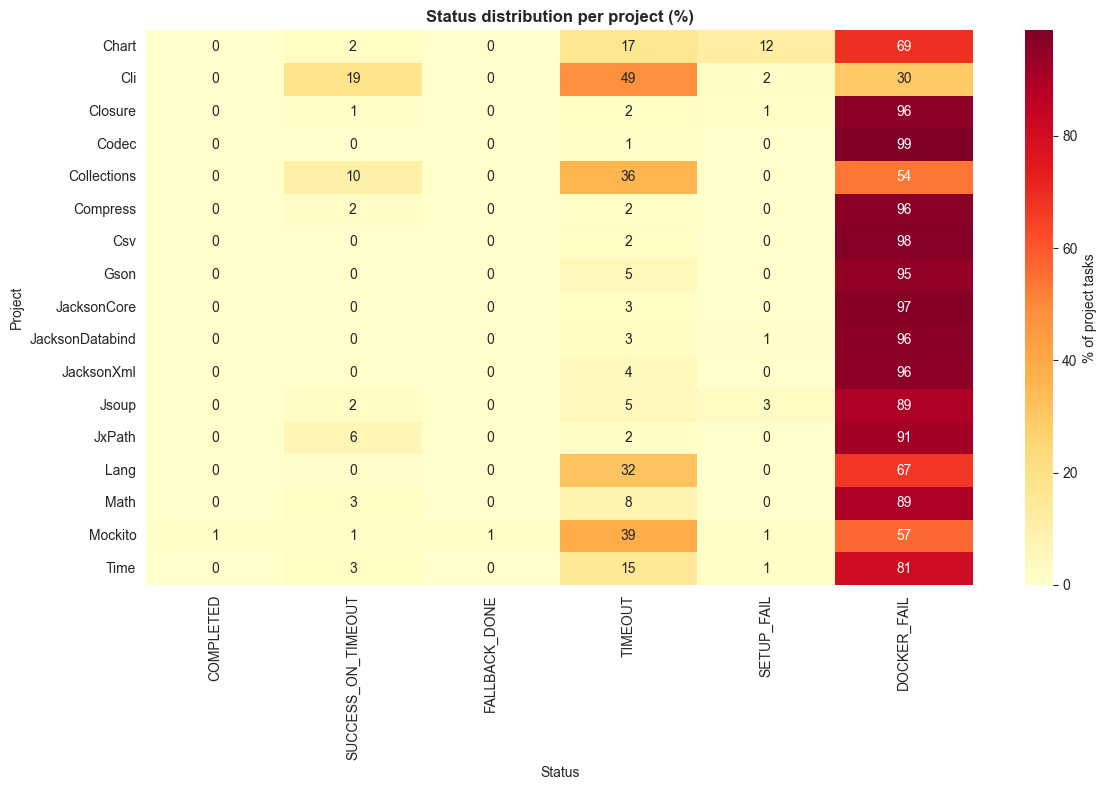

📌 สรุปความหมาย:
  - งานที่ล้มเหลวทั้งหมด 6,599 งาน, สาเหตุหลัก: DOCKER_FAIL 73%, TIMEOUT 24%, FALLBACK_SUMMARY 2%
  - โปรเจกต์ที่ TIMEOUT สูงสุด: Cli (49%)


In [25]:
key = [s for s in ['COMPLETED', 'SUCCESS_ON_TIMEOUT', 'FALLBACK_DONE', 'TIMEOUT', 'SETUP_FAIL', 'DOCKER_FAIL']
       if s in ext['Status'].unique()]
pv = ext[ext['Status'].isin(key)].groupby(['Project', 'Status']).size().unstack(fill_value=0)[key]
pv_pct = pv.div(pv.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pv_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '% of project tasks'})
ax.set_title('Status distribution per project (%)', fontweight='bold')
plt.tight_layout(); plt.savefig('09_failure_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

fail = ext[ext['Group'] == 'Failed']['Status'].value_counts()
print('📌 สรุปความหมาย:')
print(f'  - งานที่ล้มเหลวทั้งหมด {fail.sum():,} งาน, สาเหตุหลัก: ' + ', '.join(f'{k} {v/fail.sum()*100:.0f}%' for k, v in fail.head(3).items()))
if 'TIMEOUT' in pv_pct:
    print(f'  - โปรเจกต์ที่ TIMEOUT สูงสุด: {pv_pct["TIMEOUT"].idxmax()} ({pv_pct["TIMEOUT"].max():.0f}%)')

## 11. Correlation Matrix
**วิธี:** Spearman correlation (ทนต่อ outlier และความสัมพันธ์ที่ไม่เป็นเส้นตรง) บนบั๊กที่ประเมินได้
**การอ่าน:** |ρ| < 0.3 อ่อน, 0.3–0.5 ปานกลาง, > 0.5 สูง (ความสัมพันธ์ไม่ใช่เหตุและผล)

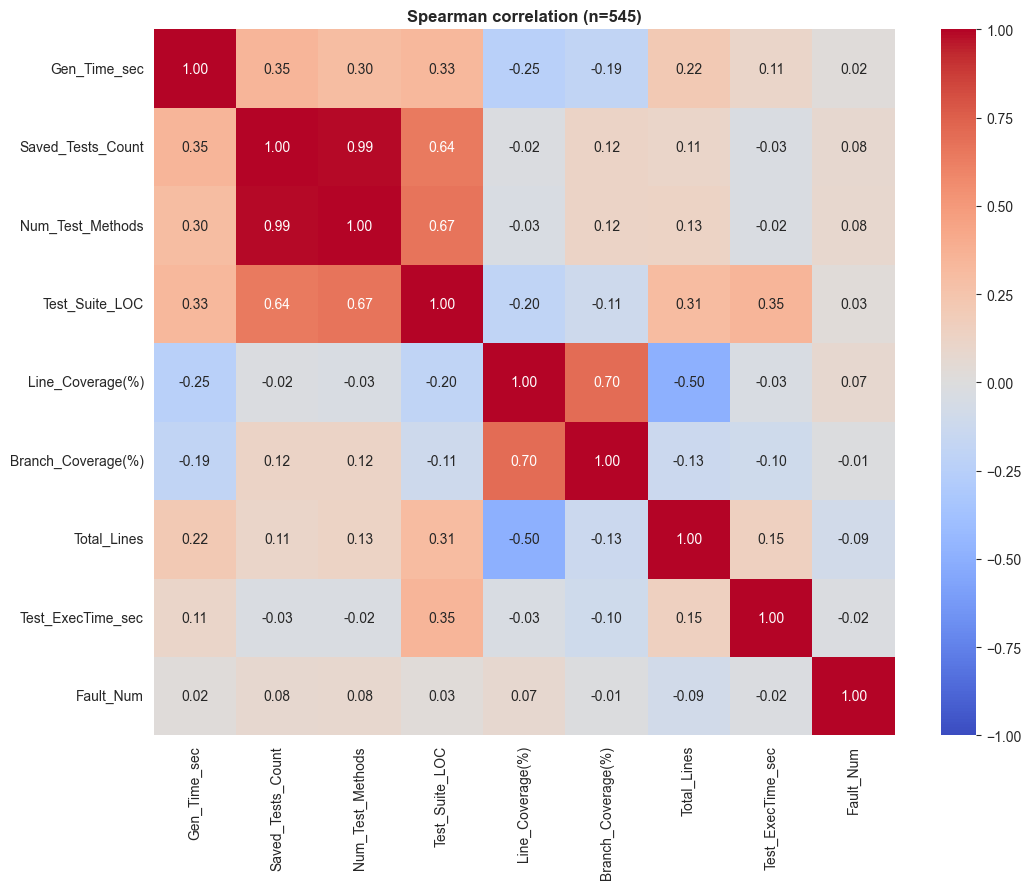

📌 คู่ที่สัมพันธ์กันมากที่สุด 5 อันดับ:
  - Saved_Tests_Count ↔ Num_Test_Methods: ρ=0.99
  - Line_Coverage(%) ↔ Branch_Coverage(%): ρ=0.70
  - Num_Test_Methods ↔ Test_Suite_LOC: ρ=0.67
  - Saved_Tests_Count ↔ Test_Suite_LOC: ρ=0.64
  - Line_Coverage(%) ↔ Total_Lines: ρ=-0.50
  - ตัวแปรที่สัมพันธ์กับ Fault detection มากที่สุด: Total_Lines (ρ=-0.09)


In [26]:
fd['Fault_Num'] = (fd['Fault_Detected'] == 'YES').astype(int)
cols = ['Gen_Time_sec', 'Saved_Tests_Count', 'Num_Test_Methods', 'Test_Suite_LOC',
        'Line_Coverage(%)', 'Branch_Coverage(%)', 'Total_Lines', 'Test_ExecTime_sec', 'Fault_Num']
corr = fd[cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=corr.isna(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title(f'Spearman correlation (n={len(fd)})', fontweight='bold')
plt.tight_layout(); plt.savefig('10_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().sort_values(key=abs, ascending=False)
print('📌 คู่ที่สัมพันธ์กันมากที่สุด 5 อันดับ:')
for (a, b), r in pairs.head(5).items():
    print(f'  - {a} ↔ {b}: ρ={r:.2f}')
print(f'  - ตัวแปรที่สัมพันธ์กับ Fault detection มากที่สุด: {corr["Fault_Num"].drop("Fault_Num").abs().idxmax()} '
      f'(ρ={corr["Fault_Num"].drop("Fault_Num")[corr["Fault_Num"].drop("Fault_Num").abs().idxmax()]:.2f})')

## 12. สรุปผลการทดลอง (คำนวณจากข้อมูลทั้งหมด)

In [27]:
ok = cov[cov['Eval_Status'] == 'OK']
summary = pd.DataFrame({
    'Metric': ['Bugs in dataset', 'Bugs evaluated (OK)', 'TARDIS task success rate (%)',
               'Median generation time / bug (min)', 'Median tests per minute',
               'Mean line coverage (%)', 'Mean branch coverage (%)',
               'Fault detection rate (%)', 'Median test exec time (s)'],
    'Value': [len(cov), len(ok), round(overall, 1),
              round(cov['Gen_Time_sec'].median() / 60, 1), round(cov['Tests_per_Minute'].median(), 2),
              round(ok['Line_Coverage(%)'].mean(), 1), round(ok['Branch_Coverage(%)'].mean(), 1),
              round((ok['Fault_Detected'] == 'YES').mean() * 100, 1), round(cov['Test_ExecTime_sec'].median(), 1)],
    'Source': ['Coverage CSV', 'Eval_Status', 'Section 3', 'Gen_Time_sec', 'Tests_per_Minute',
               'Section 5', 'Section 5', 'Section 7', 'Test_ExecTime_sec'],
})
display(summary)
summary.to_csv('analysis_summary.csv', index=False)

line_p = results.get('Line_Coverage(%)', (np.nan,)*5)[2]
print('📌 Key Takeaways (สร้างจากตัวเลขด้านบน):')
print(f'  1. TARDIS รันสำเร็จ {overall:.1f}% ของงาน, สาเหตุล้มเหลวหลักคือ {fail.index[0] if len(fail) else "-"}')
print(f'  2. ใช้เวลาสร้างเทสต์ราว {cov["Gen_Time_sec"].median()/60:.1f} นาทีต่อบั๊ก (มัธยฐาน), ความสัมพันธ์ของเวลากับ coverage {rho_text(rho_t)}')
print(f'  3. Coverage เฉลี่ย Line {ok["Line_Coverage(%)"].mean():.1f}% / Branch {ok["Branch_Coverage(%)"].mean():.1f}% (n={len(ok)})')
print(f'  4. ตรวจพบพฤติกรรมของบั๊ก {(ok["Fault_Detected"]=="YES").sum()}/{len(ok)} บั๊ก')
print('  5. Coverage กับการจับบั๊ก: ' + ('ข้อมูลไม่พอ' if pd.isna(line_p) else
      f'มีนัยสำคัญ (p={line_p:.3g})' if line_p < 0.05 else f'ไม่มีนัยสำคัญ (p={line_p:.3g}) -> coverage อย่างเดียวอธิบายการจับบั๊กไม่ได้'))

,Metric,Value,Source
0,Bugs in dataset,854.00,Coverage CSV
1,Bugs evaluated (OK),545.00,Eval_Status
2,TARDIS task success rate (%),23.70,Section 3
3,Median generation time / bug (min),2.00,Gen_Time_sec
4,Median tests per minute,3.02,Tests_per_Minute
5,Mean line coverage (%),15.70,Section 5
6,Mean branch coverage (%),6.80,Section 5
7,Fault detection rate (%),2.90,Section 7
8,Median test exec time (s),7.80,Test_ExecTime_sec


📌 Key Takeaways (สร้างจากตัวเลขด้านบน):
  1. TARDIS รันสำเร็จ 23.7% ของงาน, สาเหตุล้มเหลวหลักคือ DOCKER_FAIL
  2. ใช้เวลาสร้างเทสต์ราว 2.0 นาทีต่อบั๊ก (มัธยฐาน), ความสัมพันธ์ของเวลากับ coverage อ่อน (ลบ)
  3. Coverage เฉลี่ย Line 15.7% / Branch 6.8% (n=545)
  4. ตรวจพบพฤติกรรมของบั๊ก 16/545 บั๊ก
  5. Coverage กับการจับบั๊ก: มีนัยสำคัญ (p=0.0431)


---
## 📋 ข้อจำกัดของการทดลอง (Threats to Validity)
- **Oracle direction:** เทสต์สร้างจาก Buggy version (ดู Section 7) การตีความ "Fault detected" จึงหมายถึงการตรวจพบพฤติกรรมที่เปลี่ยนไป ไม่ใช่การยืนยันว่าเทสต์ assert พฤติกรรมที่ถูกต้อง
- **ทรัพยากร:** รันบน WSL2 RAM 16 GB ใช้ timeout ต่อคลาสจำกัด (`TimeoutLimit`) ผลอาจต่ำกว่าเครื่องที่ทรัพยากรมากกว่า
- **Coverage scope:** Defects4J วัดเฉพาะคลาสที่ถูกแก้ในบั๊ก ไม่ใช่ทั้งโปรเจกต์
- **Flaky tests:** ลดผลกระทบด้วยการเทียบชื่อเทสต์ระหว่าง Buggy/Fixed แต่ไม่ได้รันซ้ำหลายรอบ